# Module 9, Recitation 1: Network Optimization

Curated by: Prof. Alexandre Jacquilllat and Shriya Karam

<a href="https://colab.research.google.com/github/yuri-spizhovyi-mit/ET6-ML/blob/main/module_9/mod9_rec1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>`


Network optimization problems are a ubiquitous class of problems that are used in a variety of applications. In this recitation, we'll see how optimization can be used to solve network problems in transportation at scale! In particular, we focus on the shortest path and assignment problem, and then characterize these as part of a broader class of problems called "network flows."

Before starting, please upload the Data.zip file!

## Data and set up

In [ ]:
%pip install pulp

# Install GLPK once per runtime
!apt-get -q update
!apt-get -q install -y glpk-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 81.2 MB/s eta 0:00:00
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,937 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages

In [ ]:
import pandas as pd
import numpy as np

from pulp import *

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import ArrowStyle
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")
!git clone https://github.com/yuri-spizhovyi-mit/ET6-ML.git
%cd ET6-ML/module_9

In [ ]:
import os, zipfile, shutil

filename = "Data_M9_R1.zip"
extract_path = "Data"

# Clean old folder if needed
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# --- Auto-fix nested "Data/Data" structure ---
nested = os.path.join(extract_path, "Data")
if os.path.exists(nested):
    for item in os.listdir(nested):
        shutil.move(os.path.join(nested, item), extract_path)
    shutil.rmtree(nested)

print("✅ Extracted and flattened successfully!")

In [ ]:
# Data Importation
node = pd.read_csv("Data/node.csv")
dist = pd.read_csv("Data/dist.csv")

node.head()

,Unnamed: 0,osmid,lat,lon,id,missing_neighbors,downtown
0,1,42421728,40.798048,-73.960044,1,False,False
1,2,42421731,40.798654,-73.961474,2,False,False
2,3,42421737,40.799244,-73.962873,3,False,False
3,4,42421741,40.800429,-73.965691,4,False,False
4,5,42421745,40.801398,-73.967996,5,False,False


In [ ]:
dist.head()

,Unnamed: 0,n1,n2,d
0,V2,1,2,138.033
1,V3,1,3,272.804
2,V1000,1,1000,86.258
3,V1001,1,1001,223.644
4,V1303,1,1303,165.397


In [ ]:
n_nodes = len(node)
m_edges = len(dist)

# Create edges and weights
edges = [(row["n1"], row["n2"]) for _, row in dist.iterrows()]
weights = {(row["n1"], row["n2"]): row["d"] for _, row in dist.iterrows()}

# Create incoming and outgoing edges dictionaries
incoming_edges = {n: [e for e in edges if e[1] == n] for n in range(1, n_nodes + 1)}
outgoing_edges = {n: [e for e in edges if e[0] == n] for n in range(1, n_nodes + 1)}

# Print basic information
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {m_edges}")
print(f"Sample of edges: {edges[:5]}")
print(f"Sample of weights: {dict(list(weights.items())[:5])}")

Number of nodes: 4505
Number of edges: 43285
Sample of edges: [(1, 2), (1, 3), (1, 1000), (1, 1001), (1, 1303)]
Sample of weights: {(1, 2): 138.033, (1, 3): 272.804, (1, 1000): 86.258, (1, 1001): 223.644, (1, 1303): 165.397}


## Shortest path

In the shortest path problem, our goal is to find a minimum-cost path from the origin to the destination we want to reach. We have the following information:

1. Set of $n$ nodes indexed by $i \in \mathscr{N}$. We define $o$ as the origin and $d$ as the destination node.
2. Set of $m$ directed arcs $\mathscr{A}$ indexed by $(i,j) \in \mathscr{A}$, where each arc starts at node $i \in \mathscr{N}$ and ends at node $j \in \mathscr{N}$. Each arc has an associated cost $c_{ij}$, which accounts for fuel, distance, etc.

We define the following decision variable:

$x_{ij} = 1$ if the path takes arc $(i,j) \in \mathscr{A}$, and 0 otherwise.

The optimization model finds the least-cost path by minimizing the total cost subject to flow balance constraints that ensure a viable path from origin to destination.

\begin{align*}
                \min		&	\quad	\sum_{(i,j) \in \mathscr{A}} c_{ij} x_{ij}		\\
                \text{s.t.}	&	\quad	\sum_{j: (o,j) \in \mathscr{A}} x_{oj} = 1
                                \\
                                & \text{(1 unit of flow leaves the origin)}
                                \\
                            &   \quad	\sum_{j: (i,j) \in \mathscr{A}} x_{ij} - \sum_{j: (j,i) \in \mathscr{A}} x_{ji} = 0, \forall i \neq o, d
                                \\
                                & \text{(Incoming flow equal to outgoing flow)}
                                \\
                		    &	\quad	\sum_{j: (j,d) \in \mathscr{A}} x_{jd}=1, \quad \forall i = 1, \cdots,n
                                \\
                                & \text{(1 unit of flow arrives at the destination)}
                                \\
                            &	\quad	x_{ij}\geq0, \quad \forall (i,j) \in \mathscr{A}
                                \\
                                & \text{(Flow is non-negative)}
                                \\
            \end{align*}

The shortest_path() function below implements the problem using real-world data!


In [ ]:
def shortest_path(
    node,
    edges,
    incoming_edges,
    outgoing_edges,
    weights,
    origin,
    destination,
    verbose=True,
):
    """
    Solves the shortest path problem
    """
    n_nodes = len(node)

    # Create supply vector
    supply = np.zeros(n_nodes)
    supply[origin - 1] = 1
    supply[destination - 1] = -1

    # Create the model
    model = LpProblem("Shortest_Path", LpMinimize)

    # Create variables
    x = LpVariable.dicts("flow", edges, lowBound=0)

    # Set objective
    model += lpSum(weights[e] * x[e] for e in edges)

    # Add flow conservation constraints
    for i in range(1, n_nodes + 1):
        outgoing_flow = lpSum(x[e] for e in outgoing_edges[i])
        incoming_flow = lpSum(x[e] for e in incoming_edges[i])
        model += outgoing_flow - incoming_flow == supply[i - 1]

    # Solve the model
    model.solve(GLPK(msg=verbose))

    if LpStatus[model.status] == "Optimal":
        # Get optimal value
        optimal_value = value(model.objective)

        # Reconstruct the path
        optimal_path = []
        current_node = origin
        visited = set()

        while current_node != destination and current_node not in visited:
            visited.add(current_node)
            for e in outgoing_edges[current_node]:
                if value(x[e]) > 0.5:
                    optimal_path.append(e)
                    current_node = e[1]
                    break

        # Convert path to DataFrame
        optimal_path_df = pd.DataFrame(optimal_path, columns=["n1", "n2"])
        return optimal_value, optimal_path_df
    else:
        print("No optimal solution found.")
        return None, None

In [ ]:
# Set origin and destination
origin = 1086
destination = 2307

# Solve shortest path problem
optimal_value, optimal_path = shortest_path(
    node,
    edges,
    incoming_edges,
    outgoing_edges,
    weights,
    origin,
    destination,
    verbose=True,
)

if optimal_path is not None:
    print(f"Optimal value: {optimal_value}")
    print("\nOptimal path:")
    print(optimal_path)

Optimal value: 7403.695000000001

Optimal path:
      n1    n2
0   1086  2905
1   2905  4057
2   4057   767
3    767  2727
4   2727  3257
5   3257  2985
6   2985  3136
7   3136  2782
8   2782   873
9    873  2953
10  2953  4100
11  4100  4101
12  4101  4464
13  4464  2125
14  2125  2724
15  2724  3520
16  3520  2955
17  2955  2760
18  2760  3224
19  3224  3222
20  3222   563
21   563  1715
22  1715  1249
23  1249  2866
24  2866  2921
25  2921    86
26    86  1662
27  1662   997
28   997  2307


### Visualize

We visualize the shortest path solution below, which shows the selected path from origin to destination in green, and the remaining nodes in gray.

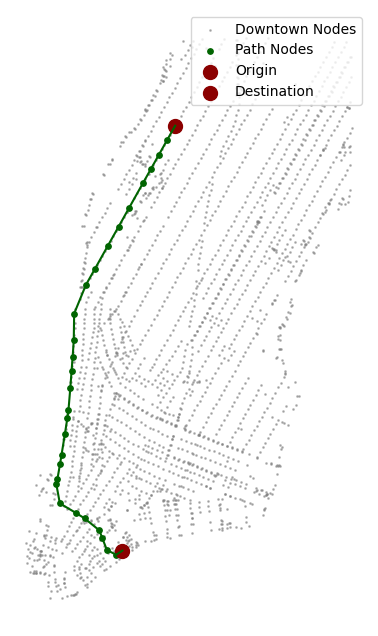

In [ ]:
# Create a copy of node data
node_SP = node.copy()

# Origin and destination nodes coordinates
target_origin = (40.707736, -74.001745)
target_destination = (40.763479, -73.992737)

# Calculate distances to target points
node_SP["dist_to_origin"] = (node_SP["lat"] - target_origin[0]) ** 2 + (
    node_SP["lon"] - target_origin[1]
) ** 2
node_SP["dist_to_destination"] = (node_SP["lat"] - target_destination[0]) ** 2 + (
    node_SP["lon"] - target_destination[1]
) ** 2

# Find closest nodes
origin_id = node_SP.loc[node_SP["dist_to_origin"].idxmin(), "id"]
destination_id = node_SP.loc[node_SP["dist_to_destination"].idxmin(), "id"]

# Mark nodes in optimal path
optimal_path_nodes = set(optimal_path["n1"]).union(set(optimal_path["n2"]))
node_SP["in_optimal_path"] = node_SP["id"].isin(optimal_path_nodes)

# Add coordinates to optimal path
optimal_path = optimal_path.merge(
    node[["id", "lat", "lon"]], left_on="n1", right_on="id", how="left"
).rename(columns={"lat": "lat_origin", "lon": "lon_origin"})

optimal_path = optimal_path.merge(
    node[["id", "lat", "lon"]], left_on="n2", right_on="id", how="left"
).rename(columns={"lat": "lat_destination", "lon": "lon_destination"})

# Create the plot
plt.figure(figsize=(6, 8))

# Plot all downtown nodes
downtown_nodes = node_SP[node_SP["downtown"]]
plt.scatter(
    downtown_nodes["lon"],
    downtown_nodes["lat"],
    color="gray",
    s=1,
    alpha=0.5,
    label="Downtown Nodes",
)

# Plot nodes in optimal path
path_nodes = node_SP[node_SP["in_optimal_path"]]
plt.scatter(
    path_nodes["lon"], path_nodes["lat"], color="darkgreen", s=15, label="Path Nodes"
)

# Plot the path segments
for _, row in optimal_path.iterrows():
    plt.plot(
        [row["lon_origin"], row["lon_destination"]],
        [row["lat_origin"], row["lat_destination"]],
        color="darkgreen",
        linewidth=1.5,
    )

# Plot origin and destination
plt.scatter(
    node_SP.loc[node_SP["id"] == origin_id, "lon"],
    node_SP.loc[node_SP["id"] == origin_id, "lat"],
    color="darkred",
    s=100,
    label="Origin",
)
plt.scatter(
    node_SP.loc[node_SP["id"] == destination_id, "lon"],
    node_SP.loc[node_SP["id"] == destination_id, "lat"],
    color="darkred",
    s=100,
    label="Destination",
)

# Set aspect ratio and remove axes
plt.gca().set_aspect(1.3)
plt.axis("off")

# Add legend
plt.legend(loc="upper right")

# Save the plot
plt.show()

In the next section, we see how the shortest path problem can be used in ride-sharing networks, where we want to match a set of drivers to riders.  

## Assignment

In the assignment problem, we want to match a set of supply resources (e.g., drivers) to a set of demand requests (e.g., riders). The cost of each assignment can be obtained from solving a shortest path problem between each driver’s location and each rider’s location (see above). The goal is to find a matching with minimum cost that serves all the demand or utilizes all the supply (or both, depending on the problem specification).

We have the following information:
1. Set of nodes $\mathscr{N}$, with $n$ total supply (driver) nodes and $m$ total demand (rider) nodes.
2. Set of $n \cdot m$ directed arcs $\mathscr{A}$ indexed by $(i,j) \in \mathscr{A}$, where each arc starts at a supply node $i = 1, ..., n$ and ends at a demand node $j = 1, ..., m$. Each arc has an associated cost $c_{ij}$ which we obtain from solving a shortest path problem for arc $(i,j)$.

We define the following decision variable:

$x_{ij} = 1$ if driver $i = 1, ..., n$ is assigned to rider $j = 1, ..., m$, and 0 otherwise.

The optimization model minimizes the total cost of the assignment subject to constraints that manage the set of supply resources and demand requests. We present the model for the balanced demand case, where each driver serves one rider, and each rider is served by one driver.

\begin{align*}
                \min		&	\quad	\sum_{i = 1}^n  \sum_{j = 1}^m c_{ij} x_{ij}		\\
                \text{s.t.}	&	\quad	\sum_{i = 1}^n x_{ij} = 1, \forall j = 1, ..., m
                                \\
                                & \text{(Each rider served by one driver)}
                                \\
                            &   \quad	\sum_{j = 1}^m x_{ij} = 1, \forall i = 1, ..., n
                                \\
                                & \text{(Each driver served by one rider)}
                                \\
                            &	\quad	x_{ij}\geq0, \quad \forall i = 1, ..., n, j = 1, ..., m
                                \\
                                & \text{(Flow is non-negative)}
                                \\
            \end{align*}

If we do *not* have balanced demand and supply, we could have the following model variants:
- *More supply (drivers) than demand (riders)*: In this case, the driver constraint becomes the following, which allows us to say that each driver need not be assigned to a rider.

$$\sum_{j = 1}^m x_{ij} \leq 1, \forall i = 1, ..., n$$

- *More demand (riders) than supply (drivers)*:  In this case, the rider constraint becomes the following, which allows us to say that each rider need not be assigned to a driver.

$$\sum_{i = 1}^n x_{ij} \leq 1, \forall j = 1, ..., m$$

The analysis is focused on the case of balanced supply and demand (where DSbalance = 2), but feel free to play around with the parameter DSbalance to see how the solution changes. Note that the shortest paths between all the nodes have already been computed, so you can just load the datasets in the next cell.

In [ ]:
# Set DSbalance (1: high demand, 2: balanced, 3: high supply)
DSbalance = 2

# Read assignment data
if DSbalance == 3:
    node_assignment = pd.read_csv("Data/Assignment/assignment_highsupply.csv")
    distance_assignment = pd.read_csv(
        "Data/Assignment/distance_assignment_highsupply.csv"
    ).iloc[:, 1:]
    distance_assignment = distance_assignment.values
elif DSbalance == 2:
    node_assignment = pd.read_csv("Data/Assignment/assignment_balanced.csv")
    distance_assignment = pd.read_csv(
        "Data/Assignment/distance_assignment_balanced.csv"
    ).iloc[:, 1:]
    distance_assignment = distance_assignment.values
else:
    node_assignment = pd.read_csv("Data/Assignment/assignment_highdemand.csv")
    distance_assignment = pd.read_csv(
        "Data/Assignment/distance_assignment_highdemand.csv"
    ).iloc[:, 1:]
    distance_assignment = distance_assignment.values

# Get demand and supply nodes
demand_nodes = node_assignment[node_assignment["demand"] == True]["id"].tolist()
supply_nodes = node_assignment[node_assignment["supply"] == True]["id"].tolist()

n = len(demand_nodes)
m = len(supply_nodes)
verbose = False

The next cell runs the assignment problem based on the formulation above!

In [ ]:
def solve_assignment(DSbalance):
    assignment_model = LpProblem("Assignment_Problem", LpMinimize)

    # Create decision variables
    x = LpVariable.dicts("x", ((i, j) for i in range(n) for j in range(m)), lowBound=0)

    # Objective function
    assignment_model += lpSum(
        distance_assignment[i, j] * x[(i, j)] for i in range(n) for j in range(m)
    )

    # Constraints based on DSbalance
    if DSbalance == 3:  # High supply
        for i in range(n):
            assignment_model += lpSum(x[(i, j)] for j in range(m)) == 1
        for j in range(m):
            assignment_model += lpSum(x[(i, j)] for i in range(n)) <= 1
    elif DSbalance == 2:  # Balanced
        for i in range(n):
            assignment_model += lpSum(x[(i, j)] for j in range(m)) == 1
        for j in range(m):
            assignment_model += lpSum(x[(i, j)] for i in range(n)) == 1
    else:  # High demand
        for i in range(n):
            assignment_model += lpSum(x[(i, j)] for j in range(m)) <= 1
        for j in range(m):
            assignment_model += lpSum(x[(i, j)] for i in range(n)) == 1

    # Solve the problem
    assignment_model.solve(GLPK(msg=1))

    # Get optimal solution
    optimal_value = value(assignment_model.objective)
    xOPT = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            xOPT[i, j] = value(x[(i, j)])

    return optimal_value, xOPT


optimal_value, xOPT = solve_assignment(DSbalance)
print(f"Optimal value: {optimal_value}")

Optimal value: 45083.99


### Visualize

We can visualize the arcs selected by the optimal solution below, which allows us to see which riders and drivers are matched together. In the cases where we have imbalanced demand and supply, we can see some riders or drivers that are not served or assigned at all.

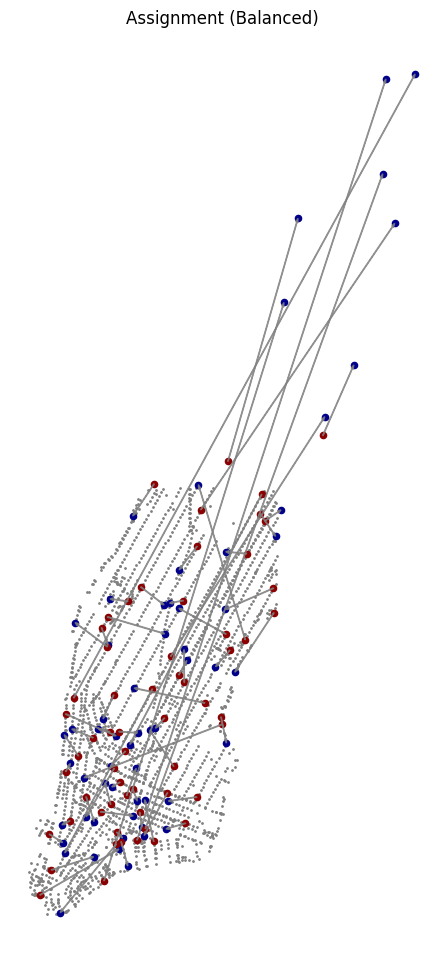

In [ ]:
def plot_assignments(node_assignment, demand_nodes, supply_nodes, optimal_assignment):
    n_demand = len(demand_nodes)
    n_supply = len(supply_nodes)

    assignment_demand_df = pd.DataFrame(index=demand_nodes)
    assignment_demand_df["lat_demand"] = node_assignment.loc[demand_nodes, "lat"]
    assignment_demand_df["lon_demand"] = node_assignment.loc[demand_nodes, "lon"]

    # Initialize other columns
    assignment_demand_df["assigned"] = -1
    assignment_demand_df["lat_assigned"] = -1
    assignment_demand_df["lon_assigned"] = -1

    for i, demand_node in enumerate(demand_nodes):
        # Optimal assignment
        assigned_node_index = np.where(optimal_assignment[i, :] == 1)[0]
        if len(assigned_node_index) > 0:
            assigned_node = supply_nodes[assigned_node_index[0]]
            assignment_demand_df.loc[demand_node, "assigned"] = assigned_node
            assignment_demand_df.loc[demand_node, "lat_assigned"] = node_assignment[
                "lat"
            ][assigned_node]
            assignment_demand_df.loc[demand_node, "lon_assigned"] = node_assignment[
                "lon"
            ][assigned_node]

    # Create supply assignment dataframe
    assignment_supply_df = pd.DataFrame(index=supply_nodes)
    assignment_supply_df["lat_supply"] = node_assignment.loc[supply_nodes, "lat"]
    assignment_supply_df["lon_supply"] = node_assignment.loc[supply_nodes, "lon"]

    # Initialize other columns
    assignment_supply_df["assigned"] = -1
    assignment_supply_df["lat_assigned"] = -1
    assignment_supply_df["lon_assigned"] = -1

    for i, supply_node in enumerate(supply_nodes):
        # Optimal assignment
        assigned_node_index = np.where(optimal_assignment[:, i] == 1)[0]
        if len(assigned_node_index) > 0:
            assigned_node = demand_nodes[assigned_node_index[0]]
            assignment_supply_df.loc[supply_node, "assigned"] = assigned_node
            assignment_supply_df.loc[supply_node, "lat_assigned"] = node_assignment[
                "lat"
            ][assigned_node]
            assignment_supply_df.loc[supply_node, "lon_assigned"] = node_assignment[
                "lon"
            ][assigned_node]

    plt.figure(figsize=(10, 12))

    # Plot downtown points (common for all cases)
    downtown_points = node_assignment[node_assignment["downtown"]]
    plt.scatter(downtown_points["lon"], downtown_points["lat"], color="gray", s=1)

    if n_demand > n_supply:
        # High demand case
        # Plot supply points
        plt.scatter(
            assignment_supply_df["lon_supply"],
            assignment_supply_df["lat_supply"],
            color="darkred",
            s=20,
        )

        # Plot demand points with color based on assignment
        for _, row in assignment_demand_df.iterrows():
            if row["assigned"] > 0:
                plt.scatter(
                    row["lon_demand"], row["lat_demand"], color="darkblue", s=20
                )
            else:
                plt.scatter(row["lon_demand"], row["lat_demand"], color="cyan", s=20)

        # Plot assignment lines with arrows
        for _, row in assignment_supply_df.iterrows():
            if row["assigned"] > 0:
                plt.arrow(
                    row["lon_supply"],
                    row["lat_supply"],
                    row["lon_assigned"] - row["lon_supply"],
                    row["lat_assigned"] - row["lat_supply"],
                    color="gray",
                    alpha=0.8,
                    width=0.0001,
                    head_width=0.0005,
                    length_includes_head=True,
                )

        assigned = plt.scatter([], [], color="darkblue", s=20, label="Rider served")
        not_assigned = plt.scatter([], [], color="cyan", s=20, label="Rider not served")
        plt.legend(handles=[assigned, not_assigned])

        plt.title("Assignment (High Demand)")
        plt.gca().set_aspect(1.3)
        plt.show()

    elif n_demand == n_supply:
        # Balanced case
        # Plot demand points
        plt.scatter(
            assignment_supply_df["lon_assigned"],
            assignment_supply_df["lat_assigned"],
            color="darkblue",
            s=20,
        )

        # Plot supply points
        plt.scatter(
            assignment_supply_df["lon_supply"],
            assignment_supply_df["lat_supply"],
            color="darkred",
            s=20,
        )

        plt.title("Assignment (Balanced)")
        plt.gca().set_aspect(1.3)
        plt.axis("off")

        # Plot assignment lines with arrows
        for _, row in assignment_supply_df.iterrows():
            if row["assigned"] > 0:
                plt.arrow(
                    row["lon_supply"],
                    row["lat_supply"],
                    row["lon_assigned"] - row["lon_supply"],
                    row["lat_assigned"] - row["lat_supply"],
                    color="gray",
                    alpha=0.8,
                    width=0.0001,
                    head_width=0.0005,
                    length_includes_head=True,
                )

        plt.show()

    else:
        # High supply case
        # Plot demand points
        plt.scatter(
            assignment_demand_df["lon_demand"],
            assignment_demand_df["lat_demand"],
            color="darkblue",
            s=20,
        )

        # Plot supply points with color based on assignment
        for _, row in assignment_supply_df.iterrows():
            if row["assigned"] > 0:
                plt.scatter(row["lon_supply"], row["lat_supply"], color="darkred", s=20)
            else:
                plt.scatter(row["lon_supply"], row["lat_supply"], color="pink", s=20)

        # Plot assignment lines
        for _, row in assignment_demand_df.iterrows():
            if row["assigned"] > 0:
                plt.arrow(
                    row["lon_assigned"],
                    row["lat_assigned"],
                    row["lon_demand"] - row["lon_assigned"],
                    row["lat_demand"] - row["lat_assigned"],
                    color="gray",
                    alpha=0.8,
                    width=0.0001,
                    head_width=0.0005,
                    length_includes_head=True,
                )

        plt.title("Assignment (High Supply)")

        assigned = plt.scatter([], [], color="darkred", s=20, label="Driver assigned")
        not_assigned = plt.scatter(
            [], [], color="pink", s=20, label="Driver not assigned"
        )
        plt.legend(handles=[assigned, not_assigned])

        plt.gca().set_aspect(1.3)
        plt.show()

    plt.close()


plot_assignments(node_assignment, demand_nodes, supply_nodes, xOPT)

### Comparison to benchmarks

When we implement optimization models, it's important to evaluate and assess *why* we need optimization models in the first place. For instance, how much better can optimization do over an approach that just assigns riders to their nearest drivers?

To answer this question, we consider two different baselines, or "benchmarks," to which we compare our optimization model. Each benchmark is carefully designed by considering the following questions:

&rarr; Motivation: what effect of the optimization do we want to isolate or show?

&rarr; Model: what is the benchmark model doing?

&rarr; Metric: how do we quantify the benefits of optimization over the benchmark?

For the assignment problem, we have a "greedy" and "closest" assignment benchmark defined below:

<table>
  <thead>
    <tr>
      <th style="text-align: center;">Benchmark</th>
      <th style="text-align: center;">Motivation</th>
      <th style="text-align: center;">Model</th>
      <th style="text-align: center;">Metric</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;"><strong>Greedy assignment</strong></td>
      <td style="text-align: center;">Show the supply/demand interdependences that an optimization model can capture over a simple approach</td>
      <td style="text-align: center;">Match each driver to a rider starting from the closest matches to the furthest, until each driver is assigned to a rider (or vice versa)</td>
      <td style="text-align: center;">Objective value difference with the optimal solution</td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Closest assignment</strong></td>
      <td style="text-align: center;">Show the complexities of the network and the need for optimization</td>
      <td style="text-align: center;">Match each rider to the nearest driver. This could result in infeasible solutions if the same driver is matched to multiple riders!</td>
      <td style="text-align: center;">Objective value difference with the optimal solution</td>
    </tr>
  </tbody>
</table>


The following function greedy_assignment_solution() implements the greedy assignment solution:

In [ ]:
# Greedy solution
def greedy_assignment_solution(distance_assignment, n_demand, n_supply):
    greedy_assignment = np.zeros((n_demand, n_supply))
    sorted_distances = np.sort(distance_assignment.flatten())
    index = 0
    served_demand = np.sum(greedy_assignment, axis=1)
    supply_used = np.sum(greedy_assignment, axis=0)

    if n_demand > n_supply or n_demand == n_supply:
        while np.sum(supply_used) < n_supply:
            index += 1
            candidate_assignment = np.where(
                distance_assignment == sorted_distances[index]
            )
            if len(candidate_assignment[0]) > 0:
                i, j = candidate_assignment[0][0], candidate_assignment[1][0]
                if served_demand[i] == 0 and supply_used[j] == 0:
                    greedy_assignment[i, j] = 1
                    served_demand = np.sum(greedy_assignment, axis=1)
                    supply_used = np.sum(greedy_assignment, axis=0)
    else:
        while np.sum(served_demand) < n_demand:
            index += 1
            candidate_assignment = np.where(
                distance_assignment == sorted_distances[index]
            )
            if len(candidate_assignment[0]) > 0:
                i, j = candidate_assignment[0][0], candidate_assignment[1][0]
                if served_demand[i] == 0 and supply_used[j] == 0:
                    greedy_assignment[i, j] = 1
                    served_demand = np.sum(greedy_assignment, axis=1)
                    supply_used = np.sum(greedy_assignment, axis=0)

    return greedy_assignment

The function create_assignment_dataframes() creates a dataframe to compare the benchmarks and optimal solution.

In [ ]:
def create_assignment_dataframes(
    node_assignment,
    demand_nodes,
    supply_nodes,
    distance_assignment,
    optimal_assignment,
    greedy_assignment,
):
    assignment_demand_df = pd.DataFrame(index=demand_nodes)

    # Initialize other columns
    assignment_demand_df["closest"] = -1
    assignment_demand_df["distance_closest"] = -1
    assignment_demand_df["assigned"] = -1
    assignment_demand_df["distance_assigned"] = -1
    assignment_demand_df["greedy"] = -1
    assignment_demand_df["distance_greedy"] = -1

    for i, demand_node in enumerate(demand_nodes):
        # Closest node
        closest_node_index = np.argmin(distance_assignment[i, :])
        closest_node = supply_nodes[closest_node_index]
        assignment_demand_df.loc[demand_node, "closest"] = closest_node
        assignment_demand_df.loc[demand_node, "distance_closest"] = distance_assignment[
            i, closest_node_index
        ]

        # Optimal assignment
        assigned_node_index = np.where(optimal_assignment[i, :] == 1)[0]
        if len(assigned_node_index) > 0:
            assigned_node = supply_nodes[assigned_node_index[0]]
            assignment_demand_df.loc[demand_node, "assigned"] = assigned_node
            assignment_demand_df.loc[demand_node, "distance_assigned"] = (
                distance_assignment[i, assigned_node_index[0]]
            )
            node_assignment[node_assignment["id"] == assigned_node].iloc[0]["lat"]

        # Greedy assignment
        greedy_node_index = np.where(greedy_assignment[i, :] == 1)[0]
        if len(greedy_node_index) > 0:
            greedy_node = supply_nodes[greedy_node_index[0]]
            assignment_demand_df.loc[demand_node, "greedy"] = greedy_node
            assignment_demand_df.loc[demand_node, "distance_greedy"] = (
                distance_assignment[i, greedy_node_index[0]]
            )

    # Create supply assignment dataframe
    assignment_supply_df = pd.DataFrame(index=supply_nodes)

    # Initialize other columns
    assignment_supply_df["closest"] = -1
    assignment_supply_df["distance_closest"] = -1
    assignment_supply_df["assigned"] = -1
    assignment_supply_df["distance_assigned"] = -1
    assignment_supply_df["greedy"] = -1
    assignment_supply_df["distance_greedy"] = -1

    for i, supply_node in enumerate(supply_nodes):
        # Closest node
        closest_node_index = np.argmin(distance_assignment[:, i])
        closest_node = demand_nodes[closest_node_index]
        assignment_supply_df.loc[supply_node, "closest"] = closest_node
        assignment_supply_df.loc[supply_node, "distance_closest"] = distance_assignment[
            closest_node_index, i
        ]

        # Optimal assignment
        assigned_node_index = np.where(optimal_assignment[:, i] == 1)[0]
        if len(assigned_node_index) > 0:
            assigned_node = demand_nodes[assigned_node_index[0]]
            assignment_supply_df.loc[supply_node, "assigned"] = assigned_node
            assignment_supply_df.loc[supply_node, "distance_assigned"] = (
                distance_assignment[assigned_node_index[0], i]
            )

        # Greedy assignment
        greedy_node_index = np.where(greedy_assignment[:, i] == 1)[0]
        if len(greedy_node_index) > 0:
            greedy_node = demand_nodes[greedy_node_index[0]]
            assignment_supply_df.loc[supply_node, "greedy"] = greedy_node
            assignment_supply_df.loc[supply_node, "distance_greedy"] = (
                distance_assignment[greedy_node_index[0], i]
            )

    return assignment_demand_df, assignment_supply_df

The function plot_distance_densities() plots the distributions of the distances for each of the benchmarks and the optimal solution.

In [ ]:
def plot_distance_densities(
    assignment_demand_df, assignment_supply_df, n_demand, n_supply
):
    plt.figure(figsize=(8, 6))

    if n_demand > n_supply:
        assessment = [
            np.sum(assignment_supply_df["distance_closest"]),
            np.sum(assignment_supply_df["distance_assigned"]),
            np.sum(assignment_supply_df["distance_greedy"]),
        ]

        distance_density_df = pd.concat(
            [
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_closest"],
                        "method": "closest",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_assigned"],
                        "method": "assigned",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_greedy"],
                        "method": "greedy",
                    }
                ),
            ]
        )

        sns.kdeplot(
            data=distance_density_df,
            x="distance",
            hue="method",
            hue_order=["closest", "optimal", "greedy"],
            fill=True,
            alpha=0.1,
        )
        plt.title("Distance Distribution (High Demand)")
        plt.show()

    elif n_demand == n_supply:
        assessment = [
            np.sum(assignment_supply_df["distance_closest"])
            + np.sum(assignment_demand_df["distance_closest"]),
            np.sum(assignment_supply_df["distance_assigned"])
            + np.sum(assignment_demand_df["distance_assigned"]),
            np.sum(assignment_supply_df["distance_greedy"])
            + np.sum(assignment_demand_df["distance_greedy"]),
        ]

        distance_density_df = pd.concat(
            [
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_closest"],
                        "method": "closest",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_assigned"],
                        "method": "assigned",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_supply_df["distance_greedy"],
                        "method": "greedy",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_closest"],
                        "method": "closest",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_assigned"],
                        "method": "assigned",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_greedy"],
                        "method": "greedy",
                    }
                ),
            ]
        )

        sns.kdeplot(
            data=distance_density_df,
            x="distance",
            hue="method",
            hue_order=["closest", "optimal", "greedy"],
            fill=True,
            alpha=0.1,
        )
        plt.xlim(0, 4000)
        plt.title("Distance Distribution (Balanced)")
        plt.show()

    else:
        assessment = [
            np.sum(assignment_demand_df["distance_closest"]),
            np.sum(assignment_demand_df["distance_assigned"]),
            np.sum(assignment_demand_df["distance_greedy"]),
        ]

        distance_density_df = pd.concat(
            [
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_closest"],
                        "method": "closest",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_assigned"],
                        "method": "assigned",
                    }
                ),
                pd.DataFrame(
                    {
                        "distance": assignment_demand_df["distance_greedy"],
                        "method": "greedy",
                    }
                ),
            ]
        )

        sns.kdeplot(
            data=distance_density_df,
            x="distance",
            hue="method",
            hue_order=["closest", "optimal", "greedy"],
            fill=True,
            alpha=0.1,
        )
        plt.title("Distance Distribution (High Supply)")
        plt.show()

    plt.close()

    print("Assessment metrics:")
    print(f"Total distance (closest): {assessment[0]}")
    print(f"Total distance (optimal): {assessment[1]}")
    print(f"Total distance (greedy): {assessment[2]}")

    return assessment

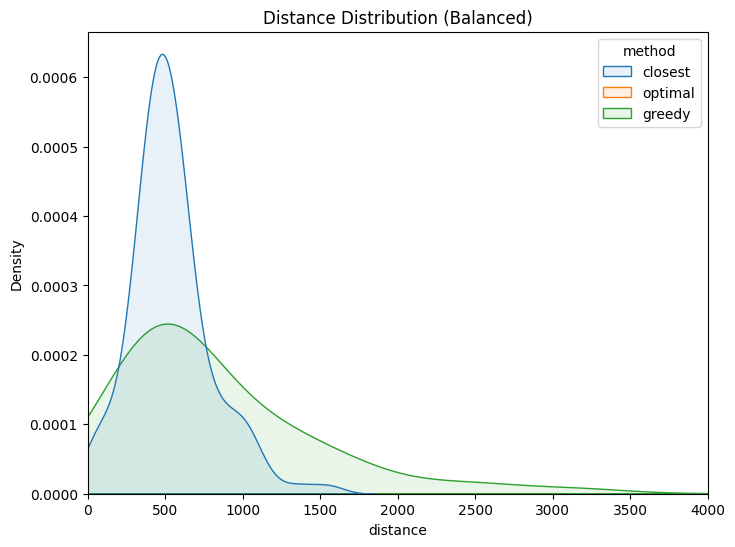

Assessment metrics:
Total distance (closest): 64248.59400000001
Total distance (optimal): 90167.98
Total distance (greedy): 107093.58000000002


In [ ]:
n_demand = len(demand_nodes)
n_supply = len(supply_nodes)

# Greedy assignment
greedy_assignment = greedy_assignment_solution(distance_assignment, n_demand, n_supply)

# Create assignment dataframes
assignment_demand_df, assignment_supply_df = create_assignment_dataframes(
    node_assignment,
    demand_nodes,
    supply_nodes,
    distance_assignment,
    xOPT,
    greedy_assignment,
)

# Plot distance densities
plot_distance_densities(assignment_demand_df, assignment_supply_df, n_demand, n_supply);

Looking at the total costs between the benchmarks and optimal solution, we see two major effects here:

- By comparing *total distance (greedy)* to *total distance (optimal)*, we see that the optimal solution results in significant improvements over a solution that just treats each rider-driver pair one at a time. This shows the benefits of optimization over a simple approach.

- By comparing *total distance (closest)* to *total distance (optimal)*, we see that the the optimal solution is worse than what could ideally be achieved by serving each rider with the nearest driver. This shows the complexity of the network as matching riders to drivers just based on shortest distance alone is not enough to ensure the supply and demand requirements! We need more complex optimization tools to ensure we have a feasible solution.

## Network flows

We next see how we can generalize the two problems we looked at - shortest path and assignment - to a broader class of optimization problems called "network flows."

In network flow problems, our goal is to match a set of supply resources (e.g., items in fulfillment centers) to a set of demand requests (e.g., customer orders). The goal is to find a shipment plan with minimum cost that serves all the demand or utilizes all the supply (or both, depending on the problem specification). Each arc in the network is capacitated, meaning that there is a limited amount of resources we can transport on each arc.

We have the following information:
1. Set of nodes $\mathscr{N}$ indexed by $i,j \in \mathscr{N}$. Each node has a value $b_i$, which denotes the net supply or demand value depending on the type of node:
    - *Supply* nodes: $b_i > 0$.
    - *Intermediate* nodes: $b_i = 0$.
    - *Demand* nodes: $b_i < 0$.
    
    <br>

2. Set of $m$ directed arcs $\mathscr{A}$ indexed by $(i,j) \in \mathscr{A}$, where each arc starts at node $i$ and ends at node $j$. Each arc has an associated cost $c_{ij}$ of sending one unit of flow along arc $(i,j) \in \mathscr{A}$, as well as a capacity $u_{ij}$, representing the maximum amount of flow that can be sent along arc $(i,j) \in \mathscr{A}$.

We define the following decision variable:

$x_{ij} =$ flow from node $i \in \mathscr{N}$ to node $j \in \mathscr{N}$.

The optimization model minimizes the total shipment cost, subject to a flow balance constraint at each node and a capacity constraint along each arc. We present the model for the balanced case where all demand is satisfied and all supply is utilized.

\begin{align*}
                \min		&	\quad	\sum_{(i,j) \in \mathscr{A}} c_{ij} x_{ij}		\\
                \text{s.t.}	&	\quad	\sum_{j: (i,j) \in \mathscr{A}} x_{ij} - \sum_{j: (j,i) \in \mathscr{A}} x_{ji} = b_i, \forall i \in \mathscr{N}
                                \\
                                & \text{(For each node, outgoing flow minus the incoming flow is equal to the net supply/demand)}
                                \\
                             &	\quad	x_{ij}\leq u_{ij}, \quad \forall (i,j) \in \mathscr{A}
                                \\
                                & \text{(Arc capacity)}
                                \\
                            &	\quad	x_{ij}\geq0, \quad \forall (i,j) \in \mathscr{A}
                                \\
                                & \text{(Flow is non-negative)}
                                \\
            \end{align*}

If we do *not* have balanced demand and supply, we could have the following cases:
- *More supply than demand*: In this case, the flow balance constraint becomes the following, which allows us to say that the outgoing flow minus the incoming flow can be less than the net supply.

$$\sum_{j: (i,j) \in \mathscr{A}} x_{ij} - \sum_{j: (j,i) \in \mathscr{A}} x_{ji} \leq b_i, \forall i \in \mathscr{N}$$

- *More demand than supply*: In this case, the flow balance constraint becomes the following, which allows us to say that the outgoing flow minus the incoming flow can be greater than the net supply.

$$\sum_{j: (i,j) \in \mathscr{A}} x_{ij} - \sum_{j: (j,i) \in \mathscr{A}} x_{ji} \geq b_i, \forall i \in \mathscr{N}$$


The analysis is focused on the case of balanced supply and demand (where DSbalance = 2), but feel free to play around with the parameter DSbalance to see how the solution changes. The solve_network_flow() solves the network flow problem using real-world data!


In [ ]:
# Set DSbalance (1: high demand, 2: balanced, 3: high supply)
DSbalance = 2

# Read network flows data
if DSbalance == 3:
    node_NF = pd.read_csv("Data/Network flow/NF_highsupply.csv")
    distance_NF = (
        pd.read_csv("Data/Network flow/distance_NF_highsupply.csv").iloc[:, 1:].values
    )
elif DSbalance == 2:
    node_NF = pd.read_csv("Data/Network flow/NF_balanced.csv")
    distance_NF = (
        pd.read_csv("Data/Network flow/distance_NF_balanced.csv").iloc[:, 1:].values
    )
else:
    node_NF = pd.read_csv("Data/Network flow/NF_highdemand.csv")
    distance_NF = (
        pd.read_csv("Data/Network flow/distance_NF_highdemand.csv").iloc[:, 1:].values
    )

# Get demand and supply nodes
demand_nodes = node_NF[node_NF["demand"] == True]["id"].tolist()
supply_nodes = node_NF[node_NF["supply"] == True]["id"].tolist()

n = len(demand_nodes)
m = len(supply_nodes)
verbose = False

In [ ]:
def solve_network_flow(DSbalance):
    # Get demand and supply nodes
    demand_nodes = node_NF.index[node_NF["demand"] > 0].tolist()
    supply_nodes = node_NF.index[node_NF["supply"] > 0].tolist()

    # Calculate net supply
    n_nodes = len(node_NF)
    net_supply = np.zeros(n_nodes)
    net_supply[demand_nodes] = -node_NF.loc[demand_nodes, "demand"].values
    net_supply[supply_nodes] = node_NF.loc[supply_nodes, "supply"].values

    # Create the optimization model
    model = LpProblem("Network_Flow", LpMinimize)

    # Create variables
    x = LpVariable.dicts("flow", edges, lowBound=0)

    # Set objective
    model += lpSum(weights[e] * x[e] for e in edges)

    # Add constraints based on balance type
    for i in range(n_nodes):
        if DSbalance == 3:
            model += (
                lpSum(x[e] for e in outgoing_edges[i + 1])
                - lpSum(x[e] for e in incoming_edges[i + 1])
                <= net_supply[i]
            )
        elif DSbalance == 2:
            model += (
                lpSum(x[e] for e in outgoing_edges[i + 1])
                - lpSum(x[e] for e in incoming_edges[i + 1])
                == net_supply[i]
            )
        else:
            model += (
                lpSum(x[e] for e in outgoing_edges[i + 1])
                - lpSum(x[e] for e in incoming_edges[i + 1])
                >= net_supply[i]
            )

    # Solve the model
    model.solve(GLPK(msg=1))

    # Get the optimal solution
    optimal_value = value(model.objective)
    xOPT = {e: value(x[e]) for e in edges}

    # Create DataFrame with optimal solution
    optimal_solution_all = pd.DataFrame(
        {
            "origin": [e[0] for e in edges],
            "destination": [e[1] for e in edges],
            "x_value": [xOPT[e] for e in edges],
        }
    )

    optimal_solution = optimal_solution_all[optimal_solution_all["x_value"] > 0]

    return optimal_value, optimal_solution


optimal_value, optimal_solution = solve_network_flow(DSbalance)
print(f"Optimal value: {optimal_value}")
print("Optimal solution:")
print(optimal_solution)

Optimal value: 5414350.420000004
Optimal solution:
       origin  destination  x_value
263        28          663     62.0
440        46         2951    109.0
454        47         2984     88.0
455        47         3023     19.0
456        47         4420     52.0
...       ...          ...      ...
42789    4450         2399     62.0
42935    4468         3481     41.0
43178    4495         1676     57.0
43189    4496         1129      2.0
43268    4504         2523     30.0

[393 rows x 3 columns]


### Visualize

We can visualize the arcs selected by the optimal solution below!

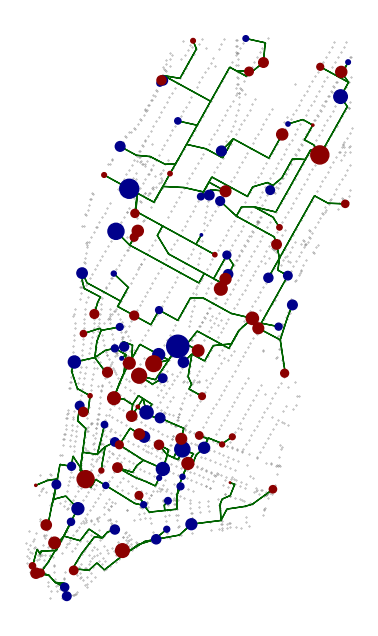

In [ ]:
def visualize_network_flow(optimal_solution):
    # Join with node data to get coordinates
    optimal_solution = optimal_solution.merge(
        node_NF[["id", "lat", "lon"]], left_on="origin", right_on="id"
    ).rename(columns={"lat": "lat_origin", "lon": "lon_origin"})

    optimal_solution = optimal_solution.merge(
        node_NF[["id", "lat", "lon"]], left_on="destination", right_on="id"
    ).rename(columns={"lat": "lat_destination", "lon": "lon_destination"})

    # Read distance data
    optimal_solution = optimal_solution.merge(
        dist, left_on=["origin", "destination"], right_on=["n1", "n2"]
    ).rename(columns={"d": "distance"})

    # Create output plot
    plt.figure(figsize=(6, 8))
    plt.scatter(
        node_NF[node_NF["downtown"]]["lon"],
        node_NF[node_NF["downtown"]]["lat"],
        color="gray",
        s=0.1,
    )

    # Plot flows
    for _, row in optimal_solution.iterrows():
        plt.arrow(
            row["lon_origin"],
            row["lat_origin"],
            row["lon_destination"] - row["lon_origin"],
            row["lat_destination"] - row["lat_origin"],
            width=row["x_value"] * 0.0000001,
            head_width=0.00000001,
            head_length=0.00000001,
            color="darkgreen",
            length_includes_head=True,
        )

    # Plot demand
    plt.scatter(
        node_NF[node_NF["demand"] > 0]["lon"],
        node_NF[node_NF["demand"] > 0]["lat"],
        s=node_NF[node_NF["demand"] > 0]["demand"] * 0.5,
        color="darkblue",
    )

    # Plot supply
    plt.scatter(
        node_NF[node_NF["supply"] > 0]["lon"],
        node_NF[node_NF["supply"] > 0]["lat"],
        s=node_NF[node_NF["supply"] > 0]["supply"] * 0.5,
        color="darkred",
    )

    plt.axis("off")
    plt.gca().set_aspect(1.3)
    plt.show()
    plt.close()

    return optimal_solution


optimal_solution = visualize_network_flow(optimal_solution)

### Comparison to benchmarks

Similar to the assignment problem, we quantify the benefits of optimization over two different "benchmarks" to compare our optimization model:
- *Greedy assignment*: To show the benefits of optimization over a simple method, we match each supply node to the nearest demand node (or vice versa) based on shortest distances, but ensure that we meet the supply and demand requirements of each node.
- *Closest assignment*: To show the complexities of the network, we match each supply node to the nearest demand node (or vice versa), without considering the demand and supply requirements for each node. This could result in infeasible solutions!

The function calculate_network_flow_benchmarks() computes the cost of each of these benchmarks and compares it to the optimal solution we obtain.

In [ ]:
def calculate_network_flow_benchmarks(optimal_solution):
    # Number of demand and supply nodes
    n_demand = len(node_NF[node_NF["demand"] > 0])
    n_supply = len(node_NF[node_NF["supply"] > 0])

    supply_quantities = node_NF[node_NF["supply"] > 0]["supply"].values
    demand_quantities = node_NF[node_NF["demand"] > 0]["demand"].values

    # Calculate the closest solution
    closest_NF = np.zeros((n_demand, n_supply))
    if n_demand > n_supply or n_demand == n_supply:
        for i in range(n_supply):
            closest_node_index = np.argmin(distance_NF[:, i])
            closest_NF[closest_node_index, i] = supply_quantities[i]
    else:
        for i in range(n_demand):
            closest_node_index = np.argmin(distance_NF[i, :])
            closest_NF[i, closest_node_index] = demand_quantities[i]

    # Calculate greedy solution
    greedy_NF = np.zeros((n_demand, n_supply))
    sorted_distances = np.sort(distance_NF.flatten())
    index = 0
    served_demand = np.sum(greedy_NF, axis=1)
    supply_used = np.sum(greedy_NF, axis=0)

    if n_demand > n_supply or n_demand == n_supply:
        while np.sum(supply_used) < np.sum(node_NF["supply"]):
            index += 1
            candidate_NF = np.where(distance_NF == sorted_distances[index])
            if len(candidate_NF[0]) > 0:
                i, j = candidate_NF[0][0], candidate_NF[1][0]
                if (
                    served_demand[i] < demand_quantities[i]
                    and supply_used[j] < supply_quantities[j]
                ):
                    greedy_NF[i, j] = min(
                        demand_quantities[i] - served_demand[i],
                        supply_quantities[j] - supply_used[j],
                    )
                    served_demand = np.sum(greedy_NF, axis=1)
                    supply_used = np.sum(greedy_NF, axis=0)
    else:
        while np.sum(served_demand) < np.sum(node_NF["demand"]):
            index += 1
            candidate_NF = np.where(distance_NF == sorted_distances[index])
            if len(candidate_NF[0]) > 0:
                i, j = candidate_NF[0][0], candidate_NF[1][0]
                if (
                    served_demand[i] < demand_quantities[i]
                    and supply_used[j] < supply_quantities[j]
                ):
                    greedy_NF[i, j] = min(
                        demand_quantities[i] - served_demand[i],
                        supply_quantities[j] - supply_used[j],
                    )
                    served_demand = np.sum(greedy_NF, axis=1)
                    supply_used = np.sum(greedy_NF, axis=0)

    # Calculate assessment metrics
    assessment = [
        n_demand,
        n_supply,
        np.sum(node_NF["demand"]),
        np.sum(node_NF["supply"]),
        round(np.sum(distance_NF * closest_NF) / 1000),
        round(
            np.sum(optimal_solution["x_value"] * optimal_solution["distance"]) / 1000
        ),
        round(np.sum(distance_NF * greedy_NF) / 1000),
    ]

    print("Assessment metrics:")
    print(f"Number of demand nodes: {assessment[0]}")
    print(f"Number of supply nodes: {assessment[1]}")
    print(f"Total demand: {assessment[2]}")
    print(f"Total supply: {assessment[3]}")
    print(f"Closest dispatch cost: {assessment[4]}k")
    print(f"Optimal cost: {assessment[5]}k")
    print(f"Greedy cost: {assessment[6]}k")


calculate_network_flow_benchmarks(optimal_solution)

Assessment metrics:
Number of demand nodes: 60
Number of supply nodes: 60
Total demand: 5557
Total supply: 5557
Closest dispatch cost: 3022k
Optimal cost: 5414k
Greedy cost: 6119k


Similar to the assignment model, we see two major effects here:
- By comparing the *closest dispatch cost* to the *optimal cost*, we show the need for complex optimization tools to ensure we have a feasible solution.

- By comparing the *greedy cost* to the *optimal cost*, we show the benefits of optimization over a simple approach.

We've seen how network flows are a broader class of problems that allow us to optimize over network structures. To recap, network flow problems are defined by the following key features:
- Decision variable: flow of goods, people, information
- Objective: minimizing total cost given as unit cost times flow quantities across all arcs
- Constraints: flow balance for demand and supply and arc capacities

## Conclusion

To put everything together, we first looked at two specific problems, the shortest path and assignment problems. It turns out that these are in fact network flow problems with the following specifications:
- Shortest path problem: supply of 1 at the origin, demand of 1 at the destination (with uncapacitated flows)
- Assignment problem: supply of 1 at each supply node, demand of 1 at each demand node (with uncapacitated flows)

Network flows are quite a pervasive class of optimization problems, with a vast range of applications!